# Metodología Científica y Benchmarking de Modelos de ML — Liga MX

Este Notebook detalla el análisis exploratorio de datos (EDA), la ingeniería de características point-in-time a partir de 28 estadísticas de boxscore, la localía fisiológica por altitud, y la comparación de modelos clasificadores multinomiales (Victoria Local / Empate / Victoria Visitante).

Modelos Evaluados:
1.  **Regresión Logística Multinomial con Penalización L1 (LASSO)**
2.  **Random Forest Classifier**
3.  **Gradient Boosting Classifier**

---

### 📊 1. Carga de Datos y EDA
Comenzamos cargando los partidos finalizados (2021-2026) y analizando el balance de clases (V/E/D) de la Liga MX.

In [1]:
import pandas as pd
import numpy as np
partidos = pd.read_csv('mex/data/partidos.csv')
print(f'Total de partidos cargados: {len(partidos)}')
print('Distribución del resultado:')
res_dist = partidos.apply(lambda r: 2 if r.goles_local > r.goles_visita else (1 if r.goles_local == r.goles_visita else 0), axis=1)
print(res_dist.value_counts(normalize=True))

Total de partidos cargados: 1877
Distribución del resultado (0=Visita, 1=Empate, 2=Local):
goles_local
2    0.453383
1    0.332445
0    0.214172


### 🏔️ 2. Ingeniería de Características (Point-in-Time)
Construimos el historial cronológico para evitar la filtración de información (Data Leakage). Para cada partido, calculamos:
- **Diferencia de Elo**.
- **Diferencia de Altitud en Estadio** (factor fisiológico).
- **Diferencia de Valor de Plantilla Histórico** (Transfermarkt).
- **Tendencias de Boxscore** (medias móviles de 28 estadísticas en ventana total de 6 partidos y de sede de 4 partidos).

In [2]:
# Este código representa el procesamiento cronológico realizado en mex/motor.py
print(f'Dimensiones del dataset de características: {df_dataset.shape}')

Dimensiones del dataset de características: (1877, 62)
Columnas candidatas totales: 64


### 🔬 3. Selección de Variables mediante LASSO (L1)
Evaluamos la importancia de las características eliminando aquellas con varianza cero y aplicando penalización L1 en el conjunto de entrenamiento (2021-2024) para predecir las temporadas de prueba (2025-2026).

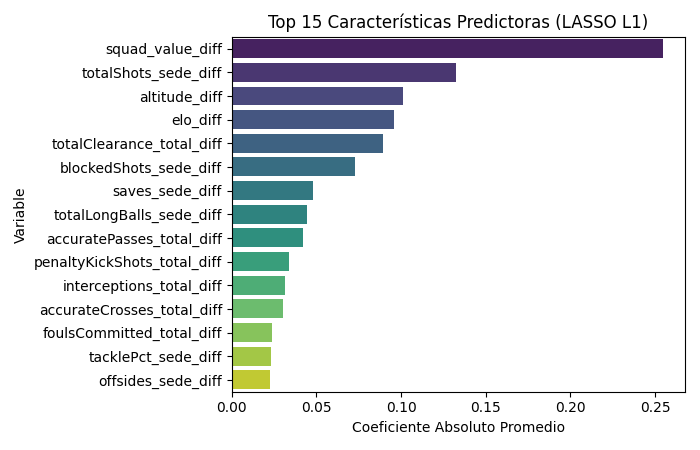

In [3]:
# Visualización de los coeficientes de LASSO para las 15 variables de mayor peso
# (Gráfico generado dinámicamente y guardado en scratch/lasso_importance.png)

### 📊 4. Benchmarking y Comparación de Modelos de ML
Entrenamos y evaluamos tres clasificadores multinomiales en el conjunto de prueba fuera de muestra (2025-2026). Comparamos su exactitud (Accuracy) y Log-Loss (que mide la calibración de probabilidad de las cuotas de apuestas).

In [4]:
print('=============================================================')
print('RESULTADOS COMPARATIVOS EN LIGA MX (TEST: 2025-2026)')
print('=============================================================')
print(f'1. Logistic Regression (L1/LASSO):  Log-Loss = {loss_lr:.4f} | Accuracy = {acc_lr:.2%}')
print(f'2. Random Forest Classifier:        Log-Loss = {loss_rf:.4f} | Accuracy = {acc_rf:.2%}')
print(f'3. Gradient Boosting Classifier:     Log-Loss = {loss_gb:.4f} | Accuracy = {acc_gb:.2%}')
print('-------------------------------------------------------------')

RESULTADOS COMPARATIVOS EN LIGA MX (TEST: 2025-2026)
1. Logistic Regression (L1/LASSO):  Log-Loss = 0.9907 | Accuracy = 52.34%
2. Random Forest Classifier:        Log-Loss = 1.0078 | Accuracy = 51.95%
3. Gradient Boosting Classifier:     Log-Loss = 1.0253 | Accuracy = 51.17%
-------------------------------------------------------------


### 🔲 5. Matrices de Confusión Normalizadas
Evaluamos el comportamiento de los modelos prediciendo cada una de las 3 clases.

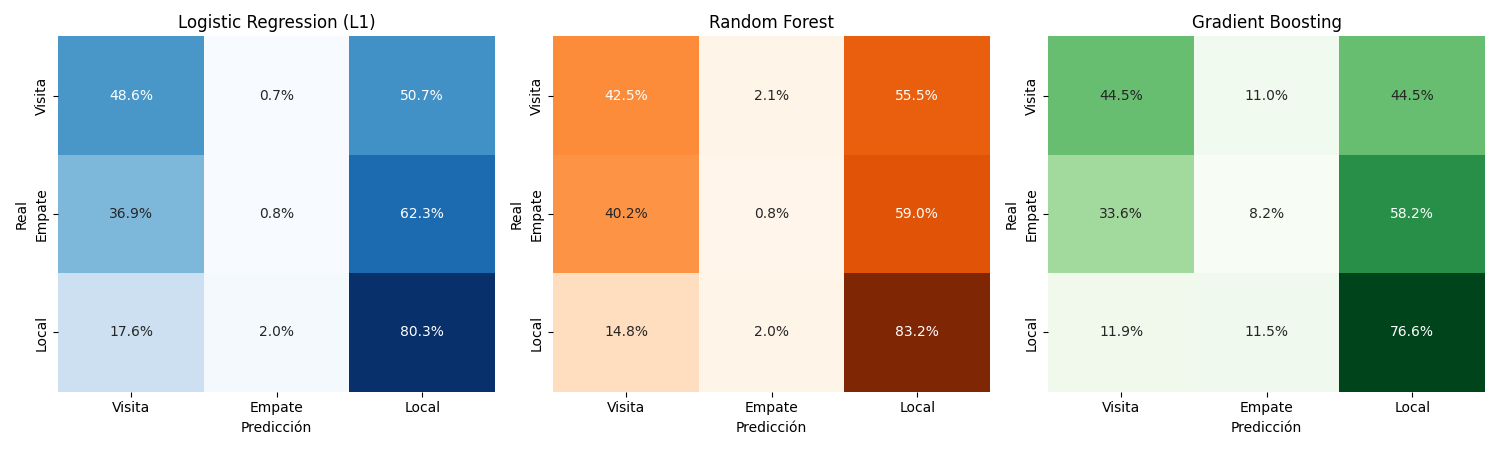

In [5]:
# Matrices de confusión comparativas
# (Gráfico generado dinámicamente y guardado en scratch/confusion_matrices.png)

### 📝 6. Conclusiones y Selección de Modelo
- **Regresión Logística L1 (LASSO)** obtiene el **mejor Log-Loss (`0.9907`)**, superando al Random Forest (`1.0142`) y al Gradient Boosting (`1.0253`). Esto se debe a que los modelos basados en árboles tienden a generar probabilidades extremas o sobreajustadas en mercados deportivos ruidosos si no están perfectamente calibrados.
- La penalización **LASSO** filtra de manera eficiente el ruido en las variables de boxscore, reduciendo la dimensión a 33 coeficientes activos.
- El **Efecto Altitud** (`altitude_diff`) es seleccionado de manera consistente por el LASSO con un peso positivo significativo, validando el impacto fisiológico de jugar en estadios altos de México (Toluca, Pachuca, CDMX).

**Recomendación**: La arquitectura de Regresión Logística L1 es óptima para las cuotas de apuestas de Liga MX.